**The goal of this assignment is to get familiar with data visualization and preparation process.**

Qestion 01: import the provided dataset ('Fish.csv') into the notebook. (5 points)

In [ ]:
import numpy as np
import pandas as pd
fish = pd.read_csv('Fish.csv')

Question 02: use the head() function to show the first 10 rows of the dataset. (5 points)

In [ ]:
fish.head(10)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
5,Bream,450.0,26.8,29.7,34.7,13.6024,4.9274
6,Bream,500.0,26.8,29.7,34.5,14.1795,5.2785
7,Bream,390.0,27.6,30.0,35.0,12.6700,4.6900
8,Bream,450.0,27.6,30.0,35.1,14.0049,4.8438
9,Bream,500.0,28.5,30.7,36.2,14.2266,4.9594


Question 03: use the info() function to show the information of the dataset. (5 points)

In [ ]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Question 04: (10 points) <br>
a) How many datapoints do we have in this dataset? <br>
**We have 159 entries (datapoints).**

b) What types of data we have in this dataset? <br>
**We have float64 and object data types.**

Answer question 04 by double clicking on this cell the typing your answers. <br>


Question 05: use describe() function to extract some statistical information of the features/attributes in the dataset. (5 points)

In [ ]:
fish.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


Question 06: plot the histogram of features/attributes. (10 points) <br>
Make sure you have 20 bins in your histogram.

Text(0.5, 1.0, 'Width Distribution')

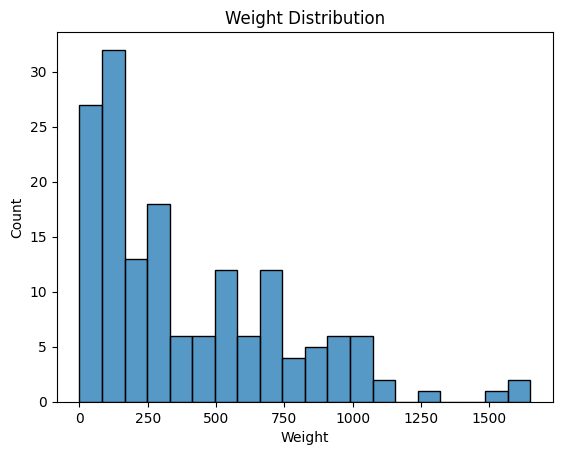

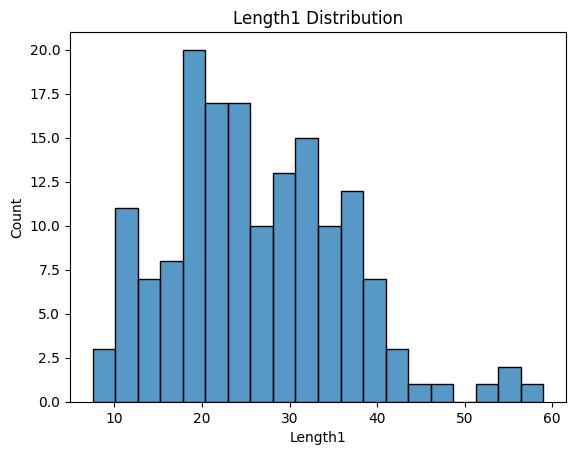

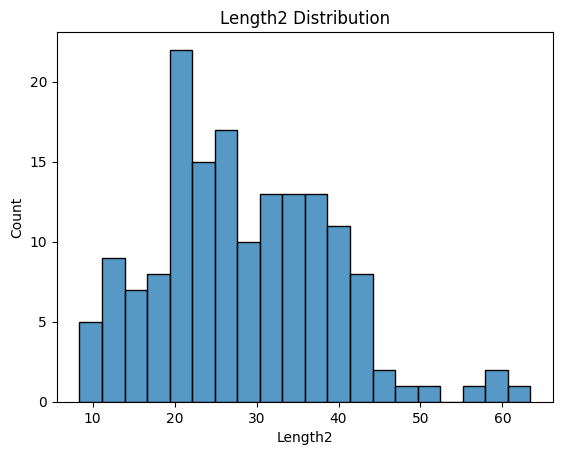

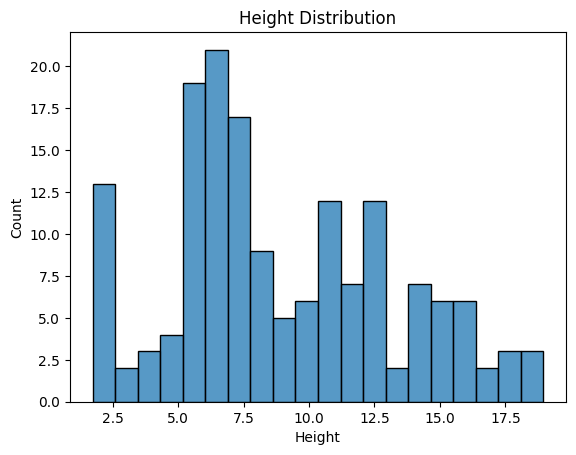

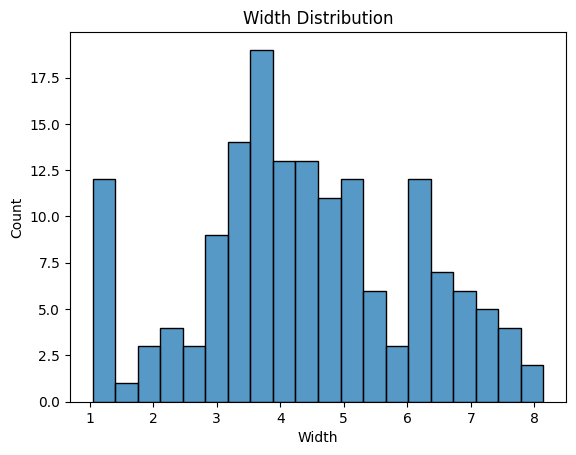

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(data=fish, x='Weight', bins = 20)
plt.title('Weight Distribution')

plt.figure()
sns.histplot(data=fish, x='Length1', bins = 20)
plt.title('Length1 Distribution')

plt.figure()
sns.histplot(data=fish, x='Length2', bins = 20)
plt.title('Length2 Distribution')

plt.figure()
sns.histplot(data=fish, x='Height', bins = 20)
plt.title('Height Distribution')

plt.figure()
sns.histplot(data=fish, x='Width', bins = 20)
plt.title('Width Distribution')


Question 07: split your dataset into the train_set and test_set. <br>
Make sure the test_set size is %10 of your dataset. (10 points)

In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(fish, test_size=.1, random_state=10)



Question 08: plot a scatter diagram with "Height" on the x-axis, "Width" on the y-axis, and a circle representing each datapoint in your dataset; the radius of each circle should represent the "Weight" of the fish. (10 points) <br>
Make sure to plot the train_set, not the whole dataset.

<Axes: xlabel='Height', ylabel='Width'>

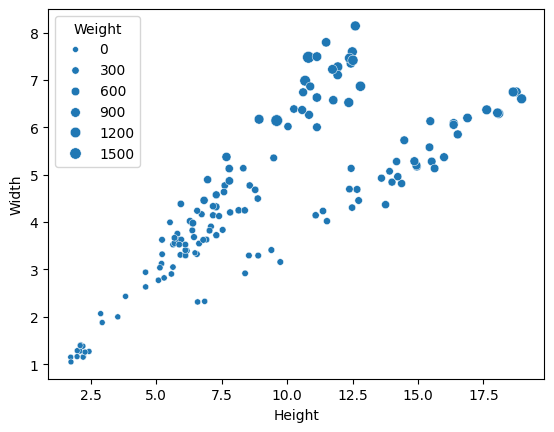

In [ ]:
sns.scatterplot(data=train_set, x='Height', y='Width', size='Weight')

Question 09: show the correlation between features/attributes using correlation matrix. (5 points)

In [ ]:
corr_matrix = train_set.drop('Species', axis=1).corr()
corr_matrix

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.917991,0.920855,0.925193,0.718473,0.886044
Length1,0.917991,1.000000,0.999524,0.992134,0.622106,0.868072
Length2,0.920855,0.999524,1.000000,0.994204,0.637059,0.874413
Length3,0.925193,0.992134,0.994204,1.000000,0.700296,0.879294
Height,0.718473,0.622106,0.637059,0.700296,1.000000,0.791565
Width,0.886044,0.868072,0.874413,0.879294,0.791565,1.000000


Question 10: show the correlation between all the features with the "Weight" of the fish. (10 points) <br>
Make sure to set ascending to False.

In [ ]:
weight_corr = corr_matrix['Weight'].sort_values(ascending=False)
weight_corr

,Weight
Weight,1.000000
Length3,0.925193
Length2,0.920855
Length1,0.917991
Width,0.886044
Height,0.718473


Question 11: split the dataset into the inputs and output. (5 points) <br>
"Weight" is the output/label/target and all the other columns are inputs.

In [ ]:
#Back to using fish
inputs = train_set.drop('Weight', axis=1)
output = train_set['Weight']

Question 12: define two pipelines for numerical and categorical values. (15 points) <br>
Make sure the numerical pipeline includes SimpleImputer and StandardScaler.
Make sure the categorical pipeline includes SimpleImputer and OneHotEncoder.
Make sure to include those pipelines in a ColumnTransformer (refer to the Data Visualization and Preparation notebook).
Make sure the output/label/"Weight" is not included in the pipeline.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('standardize', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('oneHot', OneHotEncoder()),
])

preprocessing = ColumnTransformer([
    ('numerical', numerical_pipeline, ['Length1', 'Length2', 'Length3', 'Height', 'Width']),
    ('categorical', categorical_pipeline, ['Species']),
])

Question 13: apply the pipeline to the dataset and generate prepared_dataset. (5 points)

In [ ]:
prepared_dataset = preprocessing.fit_transform(inputs)

Question 14: Consider 10% of the data as the test  (5 points).

In [ ]:
test_data = preprocessing.fit_transform(test_set)

Question 15: train a linear regression model using sklearn LinearRegression(). Then, use the trained model, do the prediction on the train dataset and calculate the RMS. (40 points)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(prepared_dataset, output)
prediction = lin_reg.predict(prepared_dataset)
lin_mse = mean_squared_error(output, prediction)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)


91.60020283274831
